# Project 22 — Breadth-First Search (BFS): London Transit Routing & N-Hop Graph Search

**Portfolio objective:** implement BFS from scratch, prove it against NetworkX, visualise the search, and connect the same N-hop idea to large-scale graph products.

**Real data:** public London Underground/DLR station and connection data from the `nicola/tubemaps` dataset. This saved run contains **302 stations, 406 line-specific connections and 349 unique station pairs**.

**Business framing:**  
- Transit: find the route with the **fewest station-to-station hops** when every edge has equal search cost.  
- Recommendation systems: BFS-style shallow graph traversal is closely related to N-hop candidate generation. LinkedIn Engineering describes 2-hop and 3-hop graph walks as a People You May Know candidate-generation technique.

Data: https://github.com/nicola/tubemaps/tree/master/datasets  
LinkedIn Engineering: https://www.linkedin.com/blog/engineering/recommendations/candidate-generation-in-a-large-scale-graph-recommendation-system-people-you-may-know

In [1]:
import math, time, heapq
from collections import deque, defaultdict
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

STATIONS_URL = "https://raw.githubusercontent.com/nicola/tubemaps/master/datasets/london.stations.csv"
CONNECTIONS_URL = "https://raw.githubusercontent.com/nicola/tubemaps/master/datasets/london.connections.csv"
LINES_URL = "https://raw.githubusercontent.com/nicola/tubemaps/master/datasets/london.lines.csv"

stations = pd.read_csv(STATIONS_URL)
connections = pd.read_csv(CONNECTIONS_URL)
lines = pd.read_csv(LINES_URL)

line_names = dict(zip(lines["line"], lines["name"]))
name_by_id = dict(zip(stations["id"], stations["name"]))
id_by_name = dict(zip(stations["name"], stations["id"]))
coords = stations.set_index("id")[["latitude","longitude"]].to_dict("index")

G = nx.Graph()
for row in stations.itertuples(index=False):
    G.add_node(int(row.id), name=row.name, latitude=float(row.latitude),
               longitude=float(row.longitude), zone=float(row.zone))

for row in connections.itertuples(index=False):
    u, v, line_id, minutes = int(row.station1), int(row.station2), int(row.line), float(row.time)
    if G.has_edge(u, v):
        G[u][v]["time"] = min(G[u][v]["time"], minutes)
        G[u][v]["lines"].add(line_id)
    else:
        G.add_edge(u, v, time=minutes, lines={line_id})

print(f"Stations: {G.number_of_nodes():,}")
print(f"Raw line-specific connections: {len(connections):,}")
print(f"Unique station-pair edges: {G.number_of_edges():,}")
print(f"Connected components: {nx.number_connected_components(G)}")

Stations: 302
Raw line-specific connections: 406
Unique station-pair edges: 349
Connected components: 1

## 1. Implement BFS from first principles

The implementation below deliberately avoids `networkx.shortest_path`. It exposes the **queue**, **parent map**, **depth map**, traversal order and reconstructed shortest path so the algorithm is interview-defensible.

In [2]:
def breadth_first_search(graph, start, target=None):
    queue = deque([start])
    parent = {start: None}
    depth = {start: 0}
    visited_order = []

    while queue:
        node = queue.popleft()
        visited_order.append(node)

        if target is not None and node == target:
            break

        for neighbour in sorted(graph.neighbors(node)):
            if neighbour not in parent:
                parent[neighbour] = node
                depth[neighbour] = depth[node] + 1
                queue.append(neighbour)

    path = None
    if target is not None and target in parent:
        path = []
        current = target
        while current is not None:
            path.append(current)
            current = parent[current]
        path.reverse()

    return {
        "path": path,
        "parent": parent,
        "depth": depth,
        "visited_order": visited_order,
    }

def route_minutes(graph, path):
    return sum(graph[u][v]["time"] for u, v in zip(path, path[1:]))

START = id_by_name["Barking"]
TARGET = id_by_name["Heathrow Terminals 1, 2 & 3"]

bfs_result = breadth_first_search(G, START, TARGET)
bfs_path = bfs_result["path"]

print("BFS route:")
print(" -> ".join(name_by_id[n] for n in bfs_path))
print(f"Fewest hops: {len(bfs_path)-1}")
print(f"Estimated edge-time along that minimum-hop path: {route_minutes(G, bfs_path):.0f} min")
print(f"Nodes dequeued before target: {len(bfs_result['visited_order'])}")

BFS route:
Barking -> East Ham -> Upton Park -> Plaistow -> West Ham -> Stratford -> Mile End -> Bethnal Green -> Liverpool Street -> Bank -> Waterloo -> Westminster -> Green Park -> Hyde Park Corner -> Knightsbridge -> South Kensington -> Gloucester Road -> Earl's Court -> Barons Court -> Hammersmith -> Turnham Green -> Acton Town -> South Ealing -> Northfields -> Boston Manor -> Osterley -> Hounslow East -> Hounslow Central -> Hounslow West -> Hatton Cross -> Heathrow Terminals 1, 2 & 3
Fewest hops: 30
Estimated edge-time along that minimum-hop path: 75 min
Nodes dequeued before target: 301

### Result interpretation

BFS finds the **minimum number of edges**, not the minimum travel time. That distinction matters: the minimum-hop Barking → Heathrow route uses **30 hops** and totals **75 minutes** using the dataset's edge-time field. In Project 24, A* optimises the weighted travel-time objective instead.

In [3]:
reference_path = nx.shortest_path(G, START, TARGET)
assert len(reference_path) == len(bfs_path)
assert len(bfs_path) - 1 == nx.shortest_path_length(G, START, TARGET)

print("Validation passed.")
print("Custom BFS hops:", len(bfs_path)-1)
print("NetworkX shortest-path hops:", len(reference_path)-1)

Validation passed.
Custom BFS hops: 30
NetworkX shortest-path hops: 30

## 2. Geographic route diagram

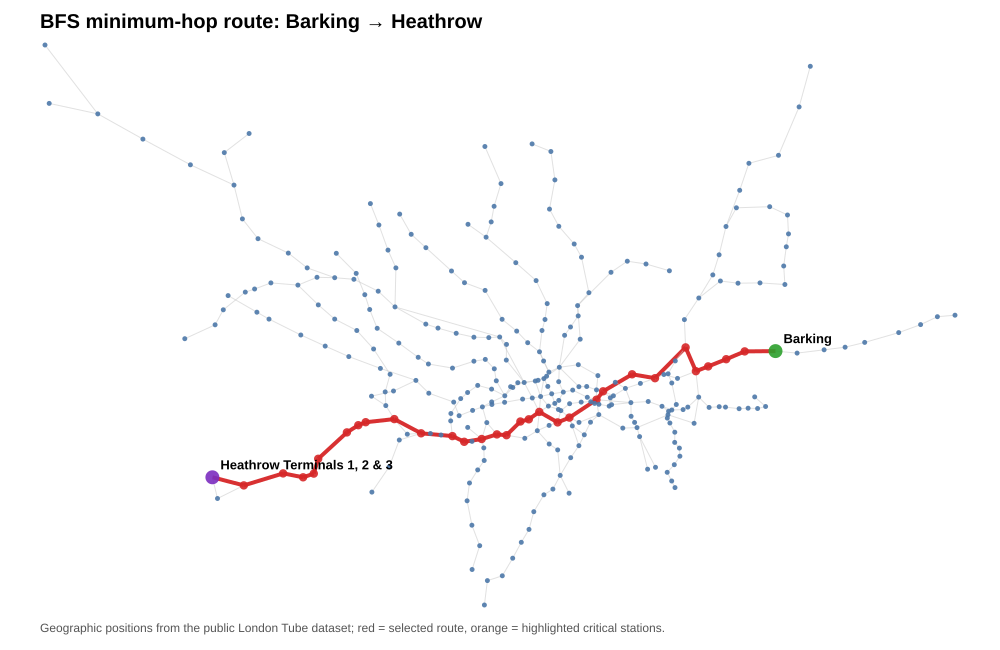

In [4]:
pos = {row.id: (row.longitude, row.latitude) for row in stations.itertuples(index=False)}
path_edges = list(zip(bfs_path, bfs_path[1:]))

plt.figure(figsize=(14, 9))
nx.draw_networkx_edges(G, pos, edge_color="lightgray", width=0.7, alpha=0.55)
nx.draw_networkx_nodes(G, pos, node_size=16, node_color="steelblue", alpha=0.75)
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="crimson", width=3.0)
nx.draw_networkx_nodes(G, pos, nodelist=bfs_path, node_size=38, node_color="crimson")
nx.draw_networkx_nodes(G, pos, nodelist=[START], node_size=120, node_color="green")
nx.draw_networkx_nodes(G, pos, nodelist=[TARGET], node_size=120, node_color="purple")
plt.title("BFS minimum-hop route: Barking to Heathrow")
plt.axis("off")
plt.show()

## 3. Search-frontier analytics

Running BFS without a target gives a complete **hop-distance map** from Barking. This is directly useful for service-radius questions such as “how many stations are within 5 or 10 transfers/edges?” and for N-hop graph retrieval.

In [5]:
full_bfs = breadth_first_search(G, START)
depth = full_bfs["depth"]

level_counts = pd.Series(depth).value_counts().sort_index()
service_area = {
    k: sum(d <= k for d in depth.values())
    for k in [5, 10, 15, 20]
}

print("Reachable stations:", len(depth))
print("Maximum BFS depth:", max(depth.values()))
print("Stations within hop radius:", service_area)
display(level_counts.rename("stations").to_frame().head(20))

Reachable stations: 302
Maximum BFS depth: 30
Stations within hop radius: {"5":13,"10":70,"15":153,"20":223}

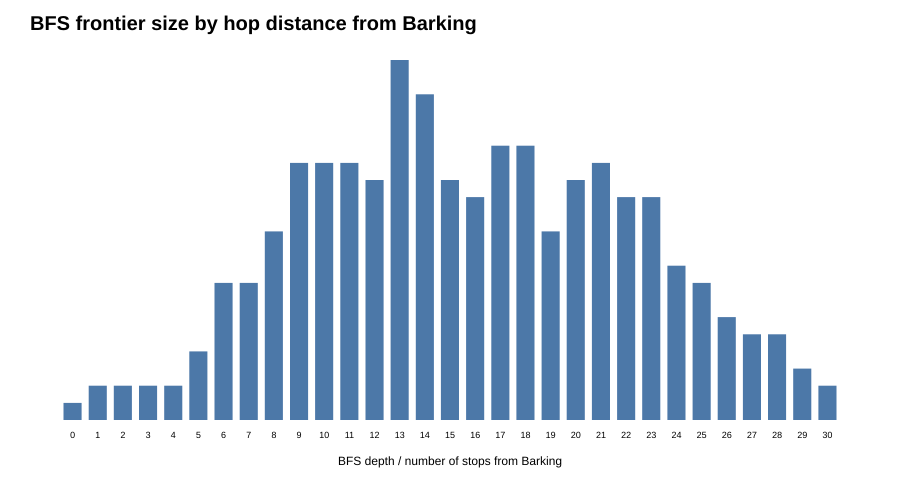

In [6]:
plt.figure(figsize=(12, 5))
level_counts.plot(kind="bar")
plt.title("BFS frontier size by hop distance from Barking")
plt.xlabel("Hop distance")
plt.ylabel("Stations discovered")
plt.tight_layout()
plt.show()

## 4. Transferable big-company connection

LinkedIn Engineering says its People You May Know candidate-generation stage uses **N-hop neighbours**, specifically 2-hop and 3-hop neighbours, and scores candidates partly by common connections. That is the same core graph primitive demonstrated here: breadth-wise traversal of a local network neighbourhood.

The production system is vastly more sophisticated and distributed; this notebook demonstrates the **algorithmic foundation**, not LinkedIn's proprietary infrastructure.

In [7]:
def n_hop_neighbourhood(graph, source, max_hops):
    result = breadth_first_search(graph, source)
    return {
        node: d for node, d in result["depth"].items()
        if 1 <= d <= max_hops
    }

two_hop = n_hop_neighbourhood(G, START, 2)
three_hop = n_hop_neighbourhood(G, START, 3)
print(f"Nodes within 2 hops of Barking: {len(two_hop)}")
print(f"Nodes within 3 hops of Barking: {len(three_hop)}")

Nodes within 2 hops of Barking: 4
Nodes within 3 hops of Barking: 6

## 5. Complexity, tests and interview takeaway

- **Time:** `O(V + E)`
- **Space:** `O(V)`
- BFS is optimal for **unweighted** shortest-path problems.
- If edge weights matter, use Dijkstra or A* rather than pretending minimum hops equals minimum time.

**Interview line:** “I implemented BFS from scratch on a real London transit graph, validated it against NetworkX, visualised the frontier, quantified N-hop service areas, and connected the same primitive to large-scale graph candidate generation.”

In [8]:
assert nx.is_connected(G)
assert bfs_path[0] == START and bfs_path[-1] == TARGET
assert len(set(bfs_result["visited_order"])) == len(bfs_result["visited_order"])
assert all(bfs_result["depth"][v] <= bfs_result["depth"][u] + 1
           for u, v in G.edges()
           if u in bfs_result["depth"] and v in bfs_result["depth"])
print("All BFS integrity checks passed ✅")

All BFS integrity checks passed ✅